# Stock Price Data Visualisation
**Maryam Chaudhry | ArithMatrix AVIP 2026 | Data Science Task 3**

This notebook creates the required files for this project, which include a runnable script and three PNG charts that show how the share price has changed, what its moving averages are, and how often different daily percentage changes occurred. It also includes a README stating that the data came from Yahoo Finance and a brief interpretation of the results.

**Default scope** - the default scope for this notebook is set to study Apple’s share prices from the 1st of January to the 31st of December 2025. You can change the company or dates in the code below.  

**AI Assistance:** I've used AI to help me create this notebook



## 1. Install the four packages
This cell installs the four Python packages used in this project: `yfinance` to download stock data, `pandas` and `numpy` to organise data and perform calculations, and `matplotlib` to create charts.


In [1]:
%pip install -q yfinance pandas numpy matplotlib


In [2]:
from pathlib import Path
from datetime import datetime, timezone
import json
import importlib.metadata
import zipfile
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display, Markdown, Image


## 2. Choose the stock and dates
This project analyses Apple (`AAPL`) from the 1st of January to the 31st of December 2025 in the `YYYY-MM-DD` format. Both the start and end dates are included in the requested range, where trading data is available.

If you'd like to analyse a different stock or period, change `TICKER`, `START_DATE` and `END_DATE`, then rerun the remaining cells. Choose a period that has at least 50 recorded trading days so both the moving averages can be calculated.

Running the export cells again replaces the generated files in `task3_output`.


In [3]:
TICKER = "AAPL"
START_DATE = "2025-01-01"
END_DATE = "2025-12-31"
OUTPUT_DIR = Path("task3_output")


## 3. Fetch the actual historical data
The stock-price data is downloaded from Yahoo Finance using `yfinance`, and Apple’s prices are in US dollars.

The setting `auto_adjust=False` keeps `Close` and `Adj Close` as separate columns. `Close` is used for the price-history chart. `Adj Close` includes Yahoo’s adjustments for corporate actions and is used for moving averages and daily returns.

**Why use adjusted prices?** Adjusted closing prices take account of events such as dividend payments. A dividend is money a company pays its shareholders. Looking only at the share price can miss that payment, so using adjusted prices gives a more complete picture of the return.

The download function normally excludes its end date. The code adds one day so that the selected end date is included when trading data is available.



In [4]:
def validate_dates(start, end):
    start, end = pd.Timestamp(start), pd.Timestamp(end)
    if pd.isna(start) or pd.isna(end) or start.tzinfo or end.tzinfo:
        raise ValueError("Use dates without timezones, in YYYY-MM-DD format.")
    if start > end:
        raise ValueError("The start date must be on or before the end date.")
    return start.normalize(), end.normalize()

def fetch_prices(ticker, start, end):
    """Both user-facing dates are inclusive; yfinance's end is exclusive."""
    import yfinance as yf
    start, end = validate_dates(start, end)
    ticker = ticker.strip().upper()
    if not ticker or any(c.isspace() for c in ticker):
        raise ValueError("Choose one ticker, such as AAPL.")
    raw = yf.download(
        ticker, start=start.strftime("%Y-%m-%d"),
        end=(end + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
        interval="1d", auto_adjust=False, actions=False,
        progress=False, threads=False, multi_level_index=False,
        keepna=True, timeout=30,
    )
    if raw is None or raw.empty:
        raise RuntimeError(
            "Yahoo returned no data. Check the ticker, dates and internet connection. "
            "If Yahoo is rate limiting, wait and rerun the download cell. "
            "Do not substitute made-up prices."
        )
    # Explicitly handle the column format if the installed version returns levels.
    if isinstance(raw.columns, pd.MultiIndex):
        for level in range(raw.columns.nlevels):
            if ticker in raw.columns.get_level_values(level):
                raw = raw.xs(ticker, level=level, axis=1)
                break
    required = ["Close", "Adj Close"]
    if not all(col in raw.columns for col in required):
        raise ValueError(f"Expected Close and Adj Close; received {list(raw.columns)}")
    raw = raw[required].copy()
    raw.index.name = "Date"
    metadata = {
        "ticker": ticker,
        "source": "Yahoo Finance via yfinance",
        "source_url": f"https://finance.yahoo.com/quote/{ticker}/history/",
        "retrieved_at_utc": datetime.now(timezone.utc).isoformat(),
        "requested_start_inclusive": start.strftime("%Y-%m-%d"),
        "requested_end_inclusive": end.strftime("%Y-%m-%d"),
        "auto_adjust": False,
        "price_basis": "Yahoo Close for price history; Adj Close for moving averages and returns",
        "software_versions": {
            name: importlib.metadata.version(name)
            for name in ["yfinance", "pandas", "numpy", "matplotlib"]
        },
    }
    return raw, metadata


In [5]:
raw, source_metadata = fetch_prices(TICKER, START_DATE, END_DATE)
print("Source:", source_metadata["source_url"])
print("Retrieved at (UTC):", source_metadata["retrieved_at_utc"])
print("Downloaded rows:", len(raw))
display(raw.head())


Source: https://finance.yahoo.com/quote/AAPL/history/
Retrieved at (UTC): 2026-09-28T16:02:29.296540+00:00
Downloaded rows: 250


,Close,Adj Close
Date,,
2025-01-02,243.850006,242.093124
2025-01-03,243.360001,241.606659
2025-01-06,245.000000,243.234848
2025-01-07,242.210007,240.464935
2025-01-08,242.699997,240.951401


**If the download fails:** check that the stock code, dates and internet connection are correct. Yahoo may temporarily limit downloads, so wait and try running the download cell again. Continue only once the price data has downloaded successfully.

## 4. Clean the data and calculate moving averages and daily returns

This step removes duplicate entries and unusable data, sorts the dates from oldest to newest, and keeps only the selected date range. It will record any removals, and there are no prices added for weekends or market holidays.

**Moving averages:** these show the average of the latest 20 or 50 available adjusted closing prices. The average updates as each new price is included. These periods count recorded trading days, not calendar days.

**Daily return:** this measures the increase or decrease from the previous available adjusted closing price. The calculation is `(current adjusted price / previous adjusted price) - 1`. The result can be expressed as a percentage.

Some starting values are left blank on purpose. The first price has no earlier price in the dataset to compare with. Similarly, the moving averages cannot start until there are 20 or 50 prices available.

If a trading-day price is missing, the next return uses the last available price, so it may cover more than one trading session.


In [6]:
def prepare_prices(raw, start, end):
    """Keep a cleaning audit and do not invent prices on non-trading days."""
    start, end = validate_dates(start, end)
    df = raw[["Close", "Adj Close"]].copy()
    audit = {"downloaded_rows": len(df)}
    df.index = pd.to_datetime(df.index, errors="coerce")
    audit["invalid_dates_removed"] = int(df.index.isna().sum())
    df = df.loc[~df.index.isna()]
    if df.index.tz is not None:
        df.index = df.index.tz_localize(None)
    df.index = df.index.normalize()
    audit["duplicate_dates_removed"] = int(df.index.duplicated(keep="last").sum())
    df = df.loc[~df.index.duplicated(keep="last")].sort_index()
    in_range = (df.index >= start) & (df.index <= end)
    audit["out_of_range_rows_removed"] = int((~in_range).sum())
    df = df.loc[in_range]
    df = df.apply(pd.to_numeric, errors="coerce")
    valid = np.isfinite(df).all(axis=1) & (df > 0).all(axis=1)
    audit["invalid_price_rows_removed"] = int((~valid).sum())
    df = df.loc[valid].copy()
    if len(df) < 3:
        raise ValueError("Select a range containing at least three valid trading observations.")
    df.index.name = "Date"
    # Windows count observations (trading sessions), not calendar days.
    df["SMA_20"] = df["Adj Close"].rolling(20, min_periods=20).mean()
    df["SMA_50"] = df["Adj Close"].rolling(50, min_periods=50).mean()
    df["Daily_Return"] = df["Adj Close"].pct_change(fill_method=None)
    audit["retained_rows"] = len(df)
    audit["actual_first_date"] = df.index[0].strftime("%Y-%m-%d")
    audit["actual_last_date"] = df.index[-1].strftime("%Y-%m-%d")
    return df, audit


In [7]:
prices, cleaning_audit = prepare_prices(raw, START_DATE, END_DATE)
display(pd.Series(cleaning_audit, name="Cleaning audit").to_frame())
display(prices.head())
display(prices.tail())
assert prices.index.is_monotonic_increasing
assert prices.index.is_unique
assert pd.isna(prices["Daily_Return"].iloc[0])  # First return is undefined.
if len(prices) < 50:
    print("Use a longer range for a fully populated 50-session moving-average chart.")


,Cleaning audit
downloaded_rows,250
invalid_dates_removed,0
duplicate_dates_removed,0
out_of_range_rows_removed,0
invalid_price_rows_removed,0
retained_rows,250
actual_first_date,2025-01-02
actual_last_date,2025-12-31


,Close,Adj Close,SMA_20,SMA_50,Daily_Return
Date,,,,,
2025-01-02,243.850006,242.093124,NaN,NaN,NaN
2025-01-03,243.360001,241.606659,NaN,NaN,-0.002009
2025-01-06,245.000000,243.234848,NaN,NaN,0.006739
2025-01-07,242.210007,240.464935,NaN,NaN,-0.011388
2025-01-08,242.699997,240.951401,NaN,NaN,0.002023


,Close,Adj Close,SMA_20,SMA_50,Daily_Return
Date,,,,,
2025-12-24,273.809998,273.066711,276.399651,270.219039,0.005324
2025-12-26,273.399994,272.657867,276.192714,270.703750,-0.001497
2025-12-29,273.760010,273.016876,275.938905,271.233301,0.001317
2025-12-30,273.079987,272.338684,275.439264,271.652845,-0.002484
2025-12-31,271.859985,271.122009,274.724709,271.849789,-0.004468


## 5. Calculate returns and volatility

**Volatility** describes how much the daily returns vary around their average. Higher volatility means more variation, not necessarily a rising or falling share price.

The code measures this using the **sample standard deviation** (`ddof=1`).

To express volatility on a yearly scale, the code multiplies daily volatility by the square root of 252, assuming 252 trading days per year. This is called **annualised volatility**. It is an approximate measure, not a prediction of future performance.

The **overall adjusted-price change** compares the last adjusted price with the first. The **mean daily return** adds the daily returns together and divides by the number of returns. These are different calculations: one describes the change across the whole period, while the other describes the average daily change.

In [8]:
def summarise(df):
    returns = df["Daily_Return"].dropna()
    return {
        "observations": len(df),
        "return_observations": len(returns),
        "first_date": df.index[0].strftime("%Y-%m-%d"),
        "last_date": df.index[-1].strftime("%Y-%m-%d"),
        "adjusted_price_change": float(df["Adj Close"].iloc[-1] / df["Adj Close"].iloc[0] - 1),
        "mean_daily_return": float(returns.mean()),
        "daily_volatility": float(returns.std(ddof=1)),
        "annualised_volatility_estimate": float(returns.std(ddof=1) * np.sqrt(252)),
        "best_daily_return": float(returns.max()),
        "worst_daily_return": float(returns.min()),
    }

def interpretation(ticker, stats):
    note = (
        f"Between {stats['first_date']} and {stats['last_date']}, {ticker}'s adjusted "
        f"closing price changed by {stats['adjusted_price_change']:+.2%} across "
        f"{stats['observations']} available trading observations. The arithmetic mean "
        f"daily return was {stats['mean_daily_return']:+.3%}. Daily volatility, measured "
        f"as the sample standard deviation of returns, was {stats['daily_volatility']:.2%}; "
        f"the annualised estimate was {stats['annualised_volatility_estimate']:.2%}, "
        f"using 252 trading sessions per year. The highest observed daily return was "
        f"{stats['best_daily_return']:+.2%}, and the smallest daily return was "
        f"{stats['worst_daily_return']:+.2%}.\n\n"
        "The 20-session moving average responds to recent changes faster than the "
        "50-session average; both lag the underlying price. The return histogram "
        "shows the frequency and spread of observed daily changes, while volatility "
        "describes their variation rather than predicting a direction. Adjusted "
        "prices account for the provider's corporate-action adjustments. Returns "
        "are calculated between consecutive available observations; data gaps can "
        "span more than one trading session. These historical results cover one "
        "stock and one selected period. They do not establish causation or forecast "
        "future performance; the annualisation is an approximation."
    )
    if len(note.split()) > 200:
        raise ValueError("The interpretation exceeds the task's 200-word limit.")
    return note


In [9]:
stats = summarise(prices)
metric_labels = {
    "adjusted_price_change": "Overall adjusted-price change",
    "mean_daily_return": "Mean daily return",
    "daily_volatility": "Daily volatility",
    "annualised_volatility_estimate": "Annualised volatility estimate",
    "best_daily_return": "Highest daily return",
    "worst_daily_return": "Lowest daily return",
}
display(pd.DataFrame({"Metric": list(metric_labels.values()),
                      "Value": [f"{stats[k]:+.3%}" for k in metric_labels]}))
note = interpretation(source_metadata["ticker"], stats)
display(Markdown(note))
print("Interpretation words:", len(note.split()), "/ 200")


,Metric,Value
0,Overall adjusted-price change,+11.991%
1,Mean daily return,+0.066%
2,Daily volatility,+2.045%
3,Annualised volatility estimate,+32.464%
4,Highest daily return,+15.329%
5,Lowest daily return,-9.246%


Between 2025-01-02 and 2025-12-31, AAPL's adjusted closing price changed by +11.99% across 250 available trading observations. The arithmetic mean daily return was +0.066%. Daily volatility, measured as the sample standard deviation of returns, was 2.05%; the annualised estimate was 32.46%, using 252 trading sessions per year. The highest observed daily return was +15.33%, and the smallest daily return was -9.25%.

The 20-session moving average responds to recent changes faster than the 50-session average; both lag the underlying price. The return histogram shows the frequency and spread of observed daily changes, while volatility describes their variation rather than predicting a direction. Adjusted prices account for the provider's corporate-action adjustments. Returns are calculated between consecutive available observations; data gaps can span more than one trading session. These historical results cover one stock and one selected period. They do not establish causation or forecast future performance; the annualisation is an approximation.

Interpretation words: 148 / 200


## 6. Create and check the three charts

**Closing-price history:** shows how Apple's closing share price changed over the selected period.

**Price and moving averages:** shows the adjusted closing price and its 20- and 50-trading-day moving averages together on one graph.

**Daily-return distribution:** groups daily percentage changes into ranges and shows how often changes in each range occurred. This chart is called a histogram. The horizontal axis shows the percentage changes, and the vertical axis shows how many recorded returns fall into each range.

Each chart is saved as a PNG image. The first chart uses `Close`. The second uses `Adj Close`, and the third uses returns calculated from `Adj Close`.


In [10]:
def export_charts(df, ticker, output):
    output = Path(output)
    output.mkdir(parents=True, exist_ok=True)
    plt.rcParams.update({"font.size": 11, "axes.spines.top": False,
                         "axes.spines.right": False, "figure.facecolor": "white"})
    caption = f"{ticker} | {df.index[0]:%d %b %Y} to {df.index[-1]:%d %b %Y} | Yahoo Finance"
    paths = []

    def save(fig, ax, filename):
        ax.grid(alpha=0.18)
        fig.text(0.08, 0.02, caption, fontsize=9, color="#555555")
        fig.tight_layout(rect=(0, 0.055, 1, 1))
        path = output / filename
        fig.savefig(path, dpi=180, facecolor="white")
        plt.close(fig)
        paths.append(path)

    fig, ax = plt.subplots(figsize=(11, 5.5))
    ax.plot(df.index, df["Close"], color="#136F63", linewidth=1.8)
    ax.set(title=f"{ticker}: closing price history", xlabel="Date",
           ylabel="Yahoo Close (quote currency)")
    save(fig, ax, "01_closing_price.png")

    fig, ax = plt.subplots(figsize=(11, 5.5))
    ax.plot(df.index, df["Adj Close"], color="#566573", alpha=0.65, label="Adjusted close")
    ax.plot(df.index, df["SMA_20"], color="#007C83", linewidth=1.8, label="20-session SMA")
    ax.plot(df.index, df["SMA_50"], color="#B7662A", linewidth=1.8, label="50-session SMA")
    ax.set(title=f"{ticker}: adjusted close and moving averages", xlabel="Date",
           ylabel="Adjusted price (quote currency)")
    if len(df) < 50:
        ax.text(0.02, 0.05, "A full 50-session average needs at least 50 observations.",
                transform=ax.transAxes, fontsize=9)
    ax.legend(frameon=False)
    save(fig, ax, "02_moving_averages.png")

    returns = df["Daily_Return"].dropna()
    fig, ax = plt.subplots(figsize=(11, 5.5))
    ax.hist(returns, bins=min(35, max(5, int(np.sqrt(len(returns))))),
            color="#007C83", edgecolor="white", alpha=0.9)
    ax.axvline(0, color="#555555", linestyle="--", linewidth=1, label="Zero return")
    ax.axvline(returns.mean(), color="#B7662A", linewidth=1.6, label="Mean return")
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))
    ax.set(title=f"{ticker}: daily returns distribution", xlabel="Daily adjusted-price return",
           ylabel="Number of observations")
    ax.legend(frameon=False)
    save(fig, ax, "03_daily_returns.png")
    return paths


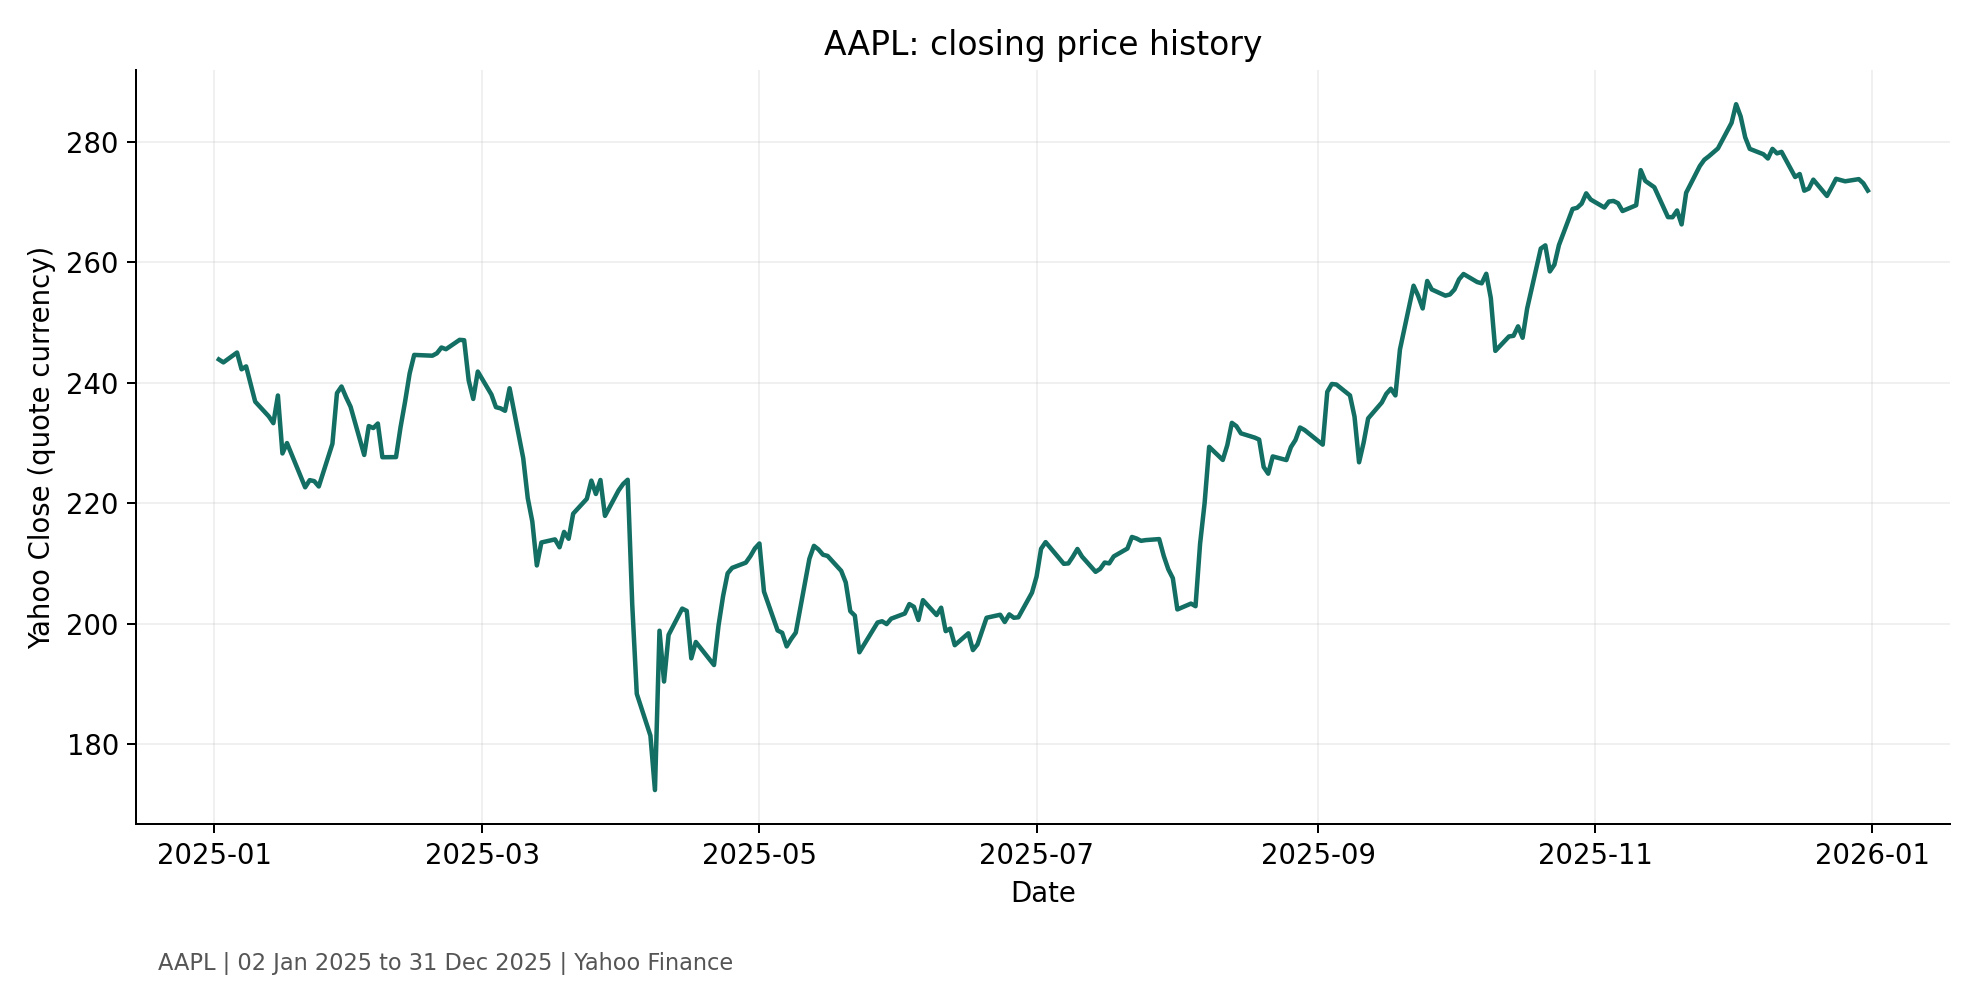

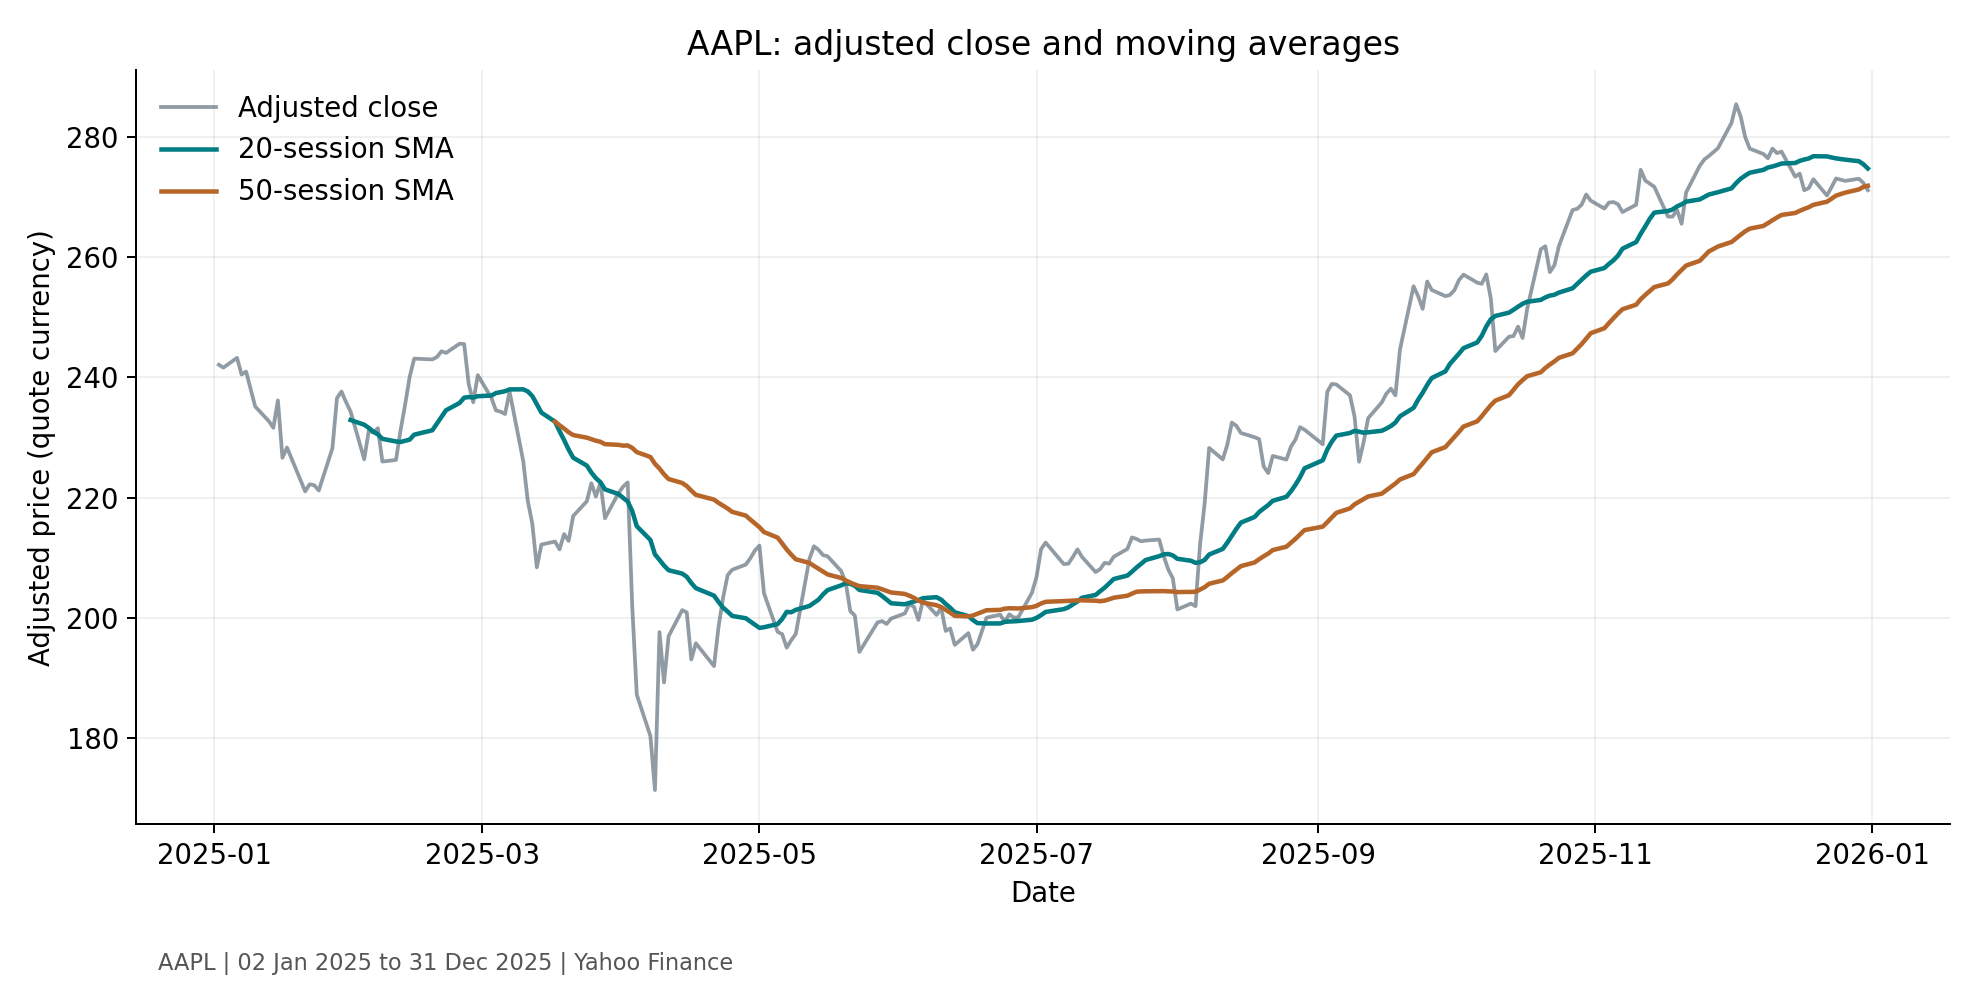

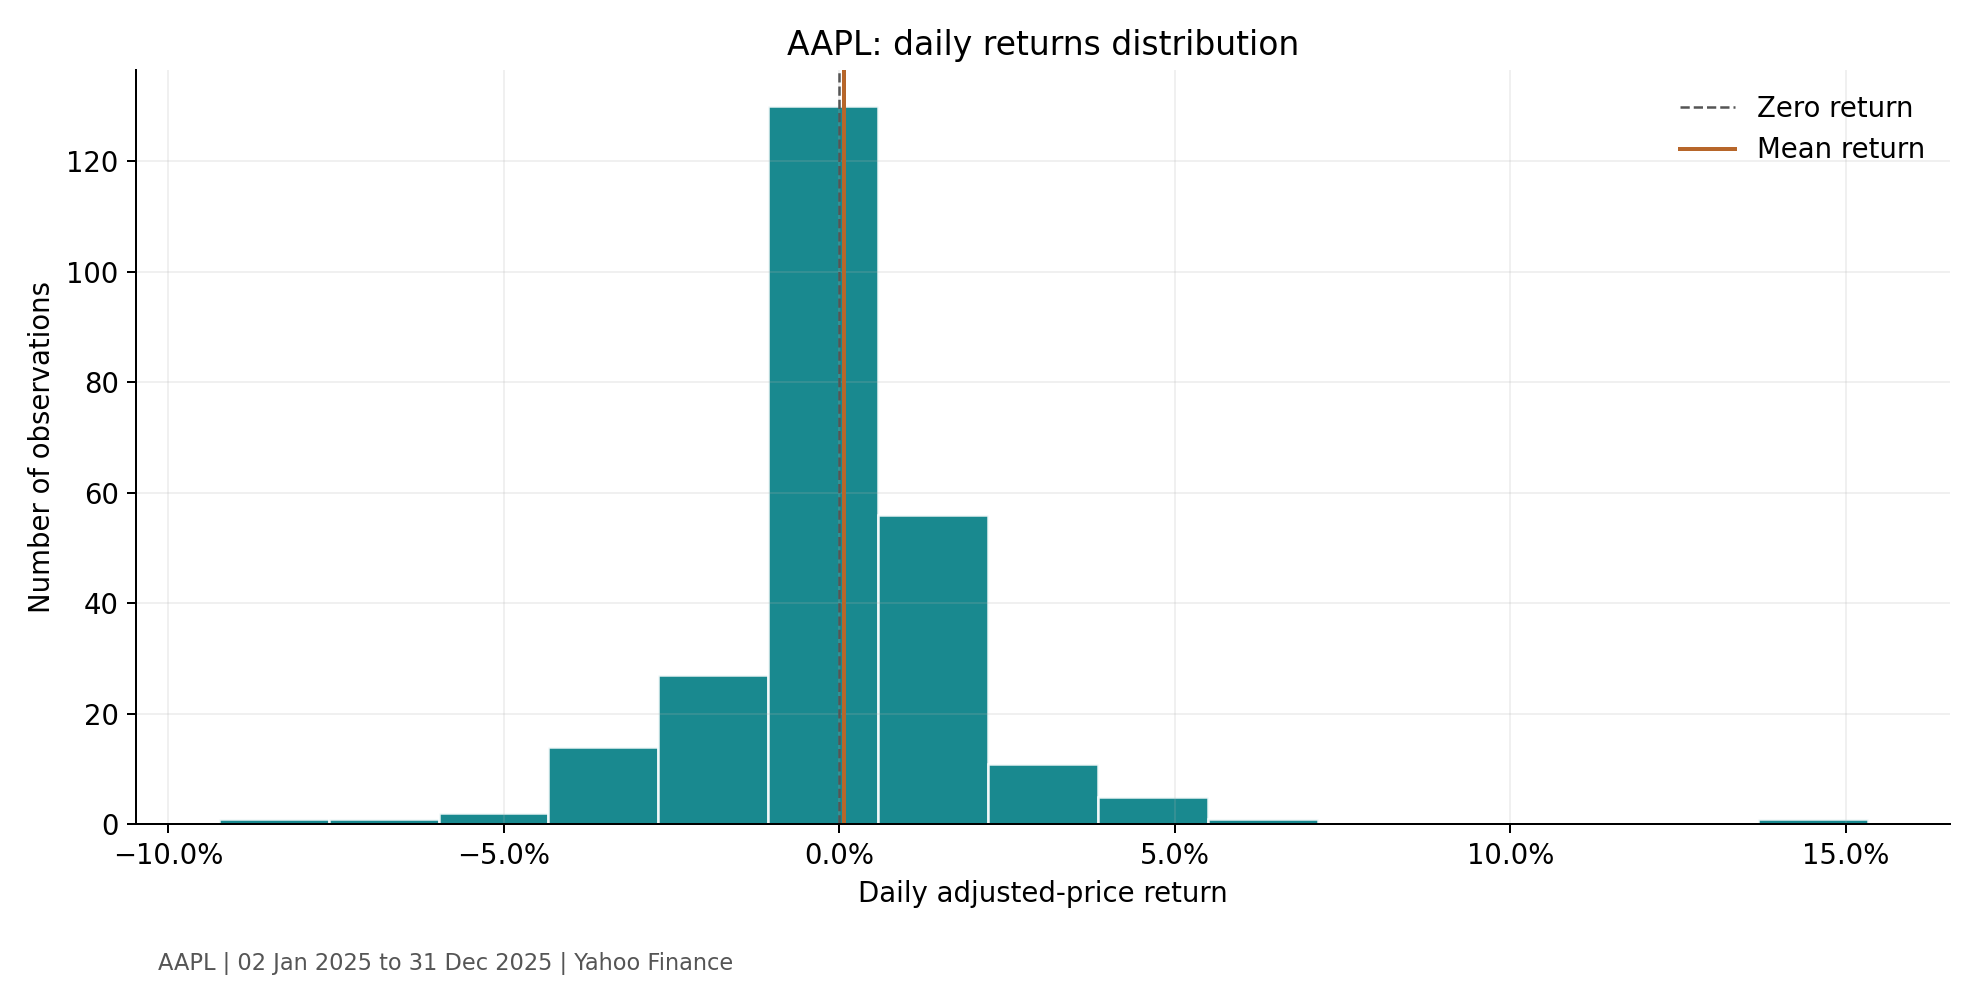

In [11]:
chart_paths = export_charts(prices, source_metadata["ticker"], OUTPUT_DIR / "charts")
for path in chart_paths:
    display(Image(filename=str(path)))


## 7. Save the README, data details and interpretation

This step saves the downloaded prices, the analysed data, and details of where the data came from and when it was downloaded. These files allow the analysis to be repeated using the same data, without downloading prices again.

The README explains how to run the project, change the date range and understand the calculations.

The interpretation explains what the results show about returns and volatility in no more than 200 words. Any changes to this explanation must stay within the word limit and be supported by the results and charts.

In [12]:
def export_report(raw, df, meta, audit, stats, note, output):
    output = Path(output)
    (output / "data").mkdir(parents=True, exist_ok=True)
    raw.to_csv(output / "data/source_prices.csv", index_label="Date")
    df.to_csv(output / "data/analysed_prices.csv", index_label="Date")
    (output / "data/source_metadata.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")
    (output / "data/cleaning_audit.json").write_text(json.dumps(audit, indent=2), encoding="utf-8")
    (output / "summary.json").write_text(json.dumps(stats, indent=2), encoding="utf-8")
    (output / "interpretation.md").write_text(note + "\n", encoding="utf-8")
    versions = meta.get("software_versions", {})
    requirements = "\n".join(f"{name}=={versions[name]}" if name in versions else name
                              for name in ["yfinance", "pandas", "numpy", "matplotlib"]) + "\n"
    (output / "requirements.txt").write_text(requirements, encoding="utf-8")
    readme = f"""# Stock Price Data Visualisation

ArithMatrix AVIP 2026 | Data Science | Task 3

## Question and scope
How did **{meta['ticker']}** prices, moving averages and daily returns behave during the selected period?
Requested dates: **{meta['requested_start_inclusive']} to {meta['requested_end_inclusive']}**, both inclusive.
Actual observations: **{stats['first_date']} to {stats['last_date']}** ({stats['observations']} rows).

## Data source
[Yahoo Finance historical prices]({meta['source_url']}) fetched with yfinance.
Extraction timestamp (UTC): **{meta['retrieved_at_utc']}**.
`data/source_metadata.json` records the download settings and library versions.
The default stock, AAPL, is quoted in USD; other tickers can use different quote currencies or units.
The saved source snapshot supports reproduction if the provider later revises historical values.

## Run from a terminal
Requires Python 3.10 or newer. From the repository folder:

```bash
python -m pip install -r requirements.txt
python stock_analysis.py --ticker {meta['ticker']} --start {meta['requested_start_inclusive']} --end {meta['requested_end_inclusive']} --output results
```

For another period, change `--start` and `--end`; choose a range with at least 50 trading observations to display both moving averages. Both dates are inclusive. Weekends and market holidays have no rows. The downloader adds one calendar day to the end because yfinance excludes its end date.

To reproduce this saved snapshot without downloading market data again:

```bash
python stock_analysis.py --csv data/source_prices.csv --metadata data/source_metadata.json --output reproduced
```

In the companion Colab notebook, edit `TICKER`, `START_DATE` and `END_DATE`, then rerun from the download cell onwards. No date-selector interface is needed because the task permits documented date-range instructions.

## Method and architecture
`stock_analysis.py` separates downloading, cleaning, calculations, chart generation and reporting into functions.

1. Keep Yahoo's `Close` and `Adj Close` as separate columns (`auto_adjust=False`). Price history uses `Close`; moving averages and returns use `Adj Close` consistently.
2. Parse dates, retain the last duplicate date, sort chronologically, filter the date range and remove invalid, non-finite or non-positive prices. Counts are in `data/cleaning_audit.json`.
3. Do not forward-fill prices or create weekend/holiday observations. Returns are between consecutive available observations, so a missing observation can create a multi-session interval.
4. Calculate trailing 20- and 50-observation simple moving averages. The first 19/49 values are intentionally missing; no future prices are used.
5. Calculate simple returns as `adjusted_close[t] / adjusted_close[t-1] - 1`. The first return is undefined and excluded from statistics.
6. Calculate sample daily volatility (`ddof=1`) and an annualised estimate using `daily_volatility * sqrt(252)`. Annualisation assumes a conventional trading-year length and is approximate.

## Required visualisations
![Closing price](charts/01_closing_price.png)
![Moving averages](charts/02_moving_averages.png)
![Daily returns](charts/03_daily_returns.png)

## Interpretation ({len(note.split())} words)
{note}

## Deliverables
- `stock_analysis.py`: runnable fetch, preparation and analysis script.
- `charts/`: three exported PNG charts.
- `interpretation.md`: interpretation of no more than 200 words.
- `data/`: source snapshot, analysed prices, provenance and cleaning audit.
- `summary.json`: calculated return and volatility metrics (returns stored as decimal fractions).
- `requirements.txt`: dependency versions used for the data run.

## Limitations
One stock and one selected period do not represent the whole market. Adjusted historical data can be revised. The analysis describes past prices, does not predict future returns, and does not model transaction costs or taxes.
"""
    (output / "README.md").write_text(readme, encoding="utf-8")


In [13]:
export_report(raw, prices, source_metadata, cleaning_audit, stats, note, OUTPUT_DIR)
print("Saved README, source data, cleaned/analysed data, audit, summary and interpretation.")


Saved README, source data, cleaned/analysed data, audit, summary and interpretation.


## 8. Save a standalone script and download the project ZIP
The script contains the same calculation functions as the notebook and can rerun the analysis from a terminal. The task accepts **a notebook or a script**, so the ZIP contains a complete script rather than depending on this Colab session.

These cells save the standalone script, check that the required files exist and contain data, and package them into a ZIP for download.


In [14]:
SCRIPT_SOURCE = '"""ArithMatrix AVIP Task 3: reproducible stock price visualisation."""\nfrom pathlib import Path\nfrom datetime import datetime, timezone\nimport argparse\nimport json\nimport importlib.metadata\n\nimport numpy as np\nimport pandas as pd\nimport matplotlib\nimport matplotlib.pyplot as plt\nfrom matplotlib.ticker import PercentFormatter\n\n\ndef validate_dates(start, end):\n    start, end = pd.Timestamp(start), pd.Timestamp(end)\n    if pd.isna(start) or pd.isna(end) or start.tzinfo or end.tzinfo:\n        raise ValueError("Use dates without timezones, in YYYY-MM-DD format.")\n    if start > end:\n        raise ValueError("The start date must be on or before the end date.")\n    return start.normalize(), end.normalize()\n\n\ndef fetch_prices(ticker, start, end):\n    """Both user-facing dates are inclusive; yfinance\'s end is exclusive."""\n    import yfinance as yf\n    start, end = validate_dates(start, end)\n    ticker = ticker.strip().upper()\n    if not ticker or any(c.isspace() for c in ticker):\n        raise ValueError("Choose one ticker, such as AAPL.")\n    raw = yf.download(\n        ticker, start=start.strftime("%Y-%m-%d"),\n        end=(end + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),\n        interval="1d", auto_adjust=False, actions=False,\n        progress=False, threads=False, multi_level_index=False,\n        keepna=True, timeout=30,\n    )\n    if raw is None or raw.empty:\n        raise RuntimeError(\n            "Yahoo returned no data. Check the ticker, dates and internet connection. "\n            "If Yahoo is rate limiting, wait and rerun the download cell. "\n            "Do not substitute made-up prices."\n        )\n    # Explicitly handle the column format if the installed version returns levels.\n    if isinstance(raw.columns, pd.MultiIndex):\n        for level in range(raw.columns.nlevels):\n            if ticker in raw.columns.get_level_values(level):\n                raw = raw.xs(ticker, level=level, axis=1)\n                break\n    required = ["Close", "Adj Close"]\n    if not all(col in raw.columns for col in required):\n        raise ValueError(f"Expected Close and Adj Close; received {list(raw.columns)}")\n    raw = raw[required].copy()\n    raw.index.name = "Date"\n    metadata = {\n        "ticker": ticker,\n        "source": "Yahoo Finance via yfinance",\n        "source_url": f"https://finance.yahoo.com/quote/{ticker}/history/",\n        "retrieved_at_utc": datetime.now(timezone.utc).isoformat(),\n        "requested_start_inclusive": start.strftime("%Y-%m-%d"),\n        "requested_end_inclusive": end.strftime("%Y-%m-%d"),\n        "auto_adjust": False,\n        "price_basis": "Yahoo Close for price history; Adj Close for moving averages and returns",\n        "software_versions": {\n            name: importlib.metadata.version(name)\n            for name in ["yfinance", "pandas", "numpy", "matplotlib"]\n        },\n    }\n    return raw, metadata\n\n\ndef prepare_prices(raw, start, end):\n    """Keep a cleaning audit and do not invent prices on non-trading days."""\n    start, end = validate_dates(start, end)\n    df = raw[["Close", "Adj Close"]].copy()\n    audit = {"downloaded_rows": len(df)}\n    df.index = pd.to_datetime(df.index, errors="coerce")\n    audit["invalid_dates_removed"] = int(df.index.isna().sum())\n    df = df.loc[~df.index.isna()]\n    if df.index.tz is not None:\n        df.index = df.index.tz_localize(None)\n    df.index = df.index.normalize()\n    audit["duplicate_dates_removed"] = int(df.index.duplicated(keep="last").sum())\n    df = df.loc[~df.index.duplicated(keep="last")].sort_index()\n    in_range = (df.index >= start) & (df.index <= end)\n    audit["out_of_range_rows_removed"] = int((~in_range).sum())\n    df = df.loc[in_range]\n    df = df.apply(pd.to_numeric, errors="coerce")\n    valid = np.isfinite(df).all(axis=1) & (df > 0).all(axis=1)\n    audit["invalid_price_rows_removed"] = int((~valid).sum())\n    df = df.loc[valid].copy()\n    if len(df) < 3:\n        raise ValueError("Select a range containing at least three valid trading observations.")\n    df.index.name = "Date"\n    # Windows count observations (trading sessions), not calendar days.\n    df["SMA_20"] = df["Adj Close"].rolling(20, min_periods=20).mean()\n    df["SMA_50"] = df["Adj Close"].rolling(50, min_periods=50).mean()\n    df["Daily_Return"] = df["Adj Close"].pct_change(fill_method=None)\n    audit["retained_rows"] = len(df)\n    audit["actual_first_date"] = df.index[0].strftime("%Y-%m-%d")\n    audit["actual_last_date"] = df.index[-1].strftime("%Y-%m-%d")\n    return df, audit\n\n\ndef summarise(df):\n    returns = df["Daily_Return"].dropna()\n    return {\n        "observations": len(df),\n        "return_observations": len(returns),\n        "first_date": df.index[0].strftime("%Y-%m-%d"),\n        "last_date": df.index[-1].strftime("%Y-%m-%d"),\n        "adjusted_price_change": float(df["Adj Close"].iloc[-1] / df["Adj Close"].iloc[0] - 1),\n        "mean_daily_return": float(returns.mean()),\n        "daily_volatility": float(returns.std(ddof=1)),\n        "annualised_volatility_estimate": float(returns.std(ddof=1) * np.sqrt(252)),\n        "best_daily_return": float(returns.max()),\n        "worst_daily_return": float(returns.min()),\n    }\n\n\ndef interpretation(ticker, stats):\n    note = (\n        f"Between {stats[\'first_date\']} and {stats[\'last_date\']}, {ticker}\'s adjusted "\n        f"closing price changed by {stats[\'adjusted_price_change\']:+.2%} across "\n        f"{stats[\'observations\']} available trading observations. The arithmetic mean "\n        f"daily return was {stats[\'mean_daily_return\']:+.3%}. Daily volatility, measured "\n        f"as the sample standard deviation of returns, was {stats[\'daily_volatility\']:.2%}; "\n        f"the annualised estimate was {stats[\'annualised_volatility_estimate\']:.2%}, "\n        f"using 252 trading sessions per year. The highest observed daily return was "\n        f"{stats[\'best_daily_return\']:+.2%}, and the smallest daily return was "\n        f"{stats[\'worst_daily_return\']:+.2%}.\\n\\n"\n        "The 20-session moving average responds to recent changes faster than the "\n        "50-session average; both lag the underlying price. The return histogram "\n        "shows the frequency and spread of observed daily changes, while volatility "\n        "describes their variation rather than predicting a direction. Adjusted "\n        "prices account for the provider\'s corporate-action adjustments. Returns "\n        "are calculated between consecutive available observations; data gaps can "\n        "span more than one trading session. These historical results cover one "\n        "stock and one selected period. They do not establish causation or forecast "\n        "future performance; the annualisation is an approximation."\n    )\n    if len(note.split()) > 200:\n        raise ValueError("The interpretation exceeds the task\'s 200-word limit.")\n    return note\n\n\ndef export_charts(df, ticker, output):\n    output = Path(output)\n    output.mkdir(parents=True, exist_ok=True)\n    plt.rcParams.update({"font.size": 11, "axes.spines.top": False,\n                         "axes.spines.right": False, "figure.facecolor": "white"})\n    caption = f"{ticker} | {df.index[0]:%d %b %Y} to {df.index[-1]:%d %b %Y} | Yahoo Finance"\n    paths = []\n\n    def save(fig, ax, filename):\n        ax.grid(alpha=0.18)\n        fig.text(0.08, 0.02, caption, fontsize=9, color="#555555")\n        fig.tight_layout(rect=(0, 0.055, 1, 1))\n        path = output / filename\n        fig.savefig(path, dpi=180, facecolor="white")\n        plt.close(fig)\n        paths.append(path)\n\n    fig, ax = plt.subplots(figsize=(11, 5.5))\n    ax.plot(df.index, df["Close"], color="#136F63", linewidth=1.8)\n    ax.set(title=f"{ticker}: closing price history", xlabel="Date",\n           ylabel="Yahoo Close (quote currency)")\n    save(fig, ax, "01_closing_price.png")\n\n    fig, ax = plt.subplots(figsize=(11, 5.5))\n    ax.plot(df.index, df["Adj Close"], color="#566573", alpha=0.65, label="Adjusted close")\n    ax.plot(df.index, df["SMA_20"], color="#007C83", linewidth=1.8, label="20-session SMA")\n    ax.plot(df.index, df["SMA_50"], color="#B7662A", linewidth=1.8, label="50-session SMA")\n    ax.set(title=f"{ticker}: adjusted close and moving averages", xlabel="Date",\n           ylabel="Adjusted price (quote currency)")\n    if len(df) < 50:\n        ax.text(0.02, 0.05, "A full 50-session average needs at least 50 observations.",\n                transform=ax.transAxes, fontsize=9)\n    ax.legend(frameon=False)\n    save(fig, ax, "02_moving_averages.png")\n\n    returns = df["Daily_Return"].dropna()\n    fig, ax = plt.subplots(figsize=(11, 5.5))\n    ax.hist(returns, bins=min(35, max(5, int(np.sqrt(len(returns))))),\n            color="#007C83", edgecolor="white", alpha=0.9)\n    ax.axvline(0, color="#555555", linestyle="--", linewidth=1, label="Zero return")\n    ax.axvline(returns.mean(), color="#B7662A", linewidth=1.6, label="Mean return")\n    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))\n    ax.set(title=f"{ticker}: daily returns distribution", xlabel="Daily adjusted-price return",\n           ylabel="Number of observations")\n    ax.legend(frameon=False)\n    save(fig, ax, "03_daily_returns.png")\n    return paths\n\n\ndef export_report(raw, df, meta, audit, stats, note, output):\n    output = Path(output)\n    (output / "data").mkdir(parents=True, exist_ok=True)\n    raw.to_csv(output / "data/source_prices.csv", index_label="Date")\n    df.to_csv(output / "data/analysed_prices.csv", index_label="Date")\n    (output / "data/source_metadata.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")\n    (output / "data/cleaning_audit.json").write_text(json.dumps(audit, indent=2), encoding="utf-8")\n    (output / "summary.json").write_text(json.dumps(stats, indent=2), encoding="utf-8")\n    (output / "interpretation.md").write_text(note + "\\n", encoding="utf-8")\n    versions = meta.get("software_versions", {})\n    requirements = "\\n".join(f"{name}=={versions[name]}" if name in versions else name\n                              for name in ["yfinance", "pandas", "numpy", "matplotlib"]) + "\\n"\n    (output / "requirements.txt").write_text(requirements, encoding="utf-8")\n    readme = f"""# Stock Price Data Visualisation\n\nArithMatrix AVIP 2026 | Data Science | Task 3\n\n## Question and scope\nHow did **{meta[\'ticker\']}** prices, moving averages and daily returns behave during the selected period?\nRequested dates: **{meta[\'requested_start_inclusive\']} to {meta[\'requested_end_inclusive\']}**, both inclusive.\nActual observations: **{stats[\'first_date\']} to {stats[\'last_date\']}** ({stats[\'observations\']} rows).\n\n## Data source\n[Yahoo Finance historical prices]({meta[\'source_url\']}) fetched with yfinance.\nExtraction timestamp (UTC): **{meta[\'retrieved_at_utc\']}**.\n`data/source_metadata.json` records the download settings and library versions.\nThe default stock, AAPL, is quoted in USD; other tickers can use different quote currencies or units.\nThe saved source snapshot supports reproduction if the provider later revises historical values.\n\n## Run from a terminal\nRequires Python 3.10 or newer. From the repository folder:\n\n```bash\npython -m pip install -r requirements.txt\npython stock_analysis.py --ticker {meta[\'ticker\']} --start {meta[\'requested_start_inclusive\']} --end {meta[\'requested_end_inclusive\']} --output results\n```\n\nFor another period, change `--start` and `--end`; choose a range with at least 50 trading observations to display both moving averages. Both dates are inclusive. Weekends and market holidays have no rows. The downloader adds one calendar day to the end because yfinance excludes its end date.\n\nTo reproduce this saved snapshot without downloading market data again:\n\n```bash\npython stock_analysis.py --csv data/source_prices.csv --metadata data/source_metadata.json --output reproduced\n```\n\nIn the companion Colab notebook, edit `TICKER`, `START_DATE` and `END_DATE`, then rerun from the download cell onwards. No date-selector interface is needed because the task permits documented date-range instructions.\n\n## Method and architecture\n`stock_analysis.py` separates downloading, cleaning, calculations, chart generation and reporting into functions.\n\n1. Keep Yahoo\'s `Close` and `Adj Close` as separate columns (`auto_adjust=False`). Price history uses `Close`; moving averages and returns use `Adj Close` consistently.\n2. Parse dates, retain the last duplicate date, sort chronologically, filter the date range and remove invalid, non-finite or non-positive prices. Counts are in `data/cleaning_audit.json`.\n3. Do not forward-fill prices or create weekend/holiday observations. Returns are between consecutive available observations, so a missing observation can create a multi-session interval.\n4. Calculate trailing 20- and 50-observation simple moving averages. The first 19/49 values are intentionally missing; no future prices are used.\n5. Calculate simple returns as `adjusted_close[t] / adjusted_close[t-1] - 1`. The first return is undefined and excluded from statistics.\n6. Calculate sample daily volatility (`ddof=1`) and an annualised estimate using `daily_volatility * sqrt(252)`. Annualisation assumes a conventional trading-year length and is approximate.\n\n## Required visualisations\n![Closing price](charts/01_closing_price.png)\n![Moving averages](charts/02_moving_averages.png)\n![Daily returns](charts/03_daily_returns.png)\n\n## Interpretation ({len(note.split())} words)\n{note}\n\n## Deliverables\n- `stock_analysis.py`: runnable fetch, preparation and analysis script.\n- `charts/`: three exported PNG charts.\n- `interpretation.md`: interpretation of no more than 200 words.\n- `data/`: source snapshot, analysed prices, provenance and cleaning audit.\n- `summary.json`: calculated return and volatility metrics (returns stored as decimal fractions).\n- `requirements.txt`: dependency versions used for the data run.\n\n## Limitations\nOne stock and one selected period do not represent the whole market. Adjusted historical data can be revised. The analysis describes past prices, does not predict future returns, and does not model transaction costs or taxes.\n"""\n    (output / "README.md").write_text(readme, encoding="utf-8")\n\n\ndef main():\n    parser = argparse.ArgumentParser(description=__doc__)\n    parser.add_argument("--ticker", default="AAPL")\n    parser.add_argument("--start", default="2025-01-01")\n    parser.add_argument("--end", default="2025-12-31")\n    parser.add_argument("--output", default="results")\n    parser.add_argument("--csv", help="Saved source CSV for offline reproduction")\n    parser.add_argument("--metadata", help="Matching source_metadata.json for offline reproduction")\n    args = parser.parse_args()\n    if bool(args.csv) != bool(args.metadata):\n        parser.error("Use --csv and --metadata together.")\n    if args.csv:\n        raw = pd.read_csv(args.csv, index_col="Date", parse_dates=True)\n        meta = json.loads(Path(args.metadata).read_text(encoding="utf-8"))\n    else:\n        raw, meta = fetch_prices(args.ticker, args.start, args.end)\n    df, audit = prepare_prices(raw, meta["requested_start_inclusive"], meta["requested_end_inclusive"])\n    stats = summarise(df)\n    note = interpretation(meta["ticker"], stats)\n    export_charts(df, meta["ticker"], Path(args.output) / "charts")\n    export_report(raw, df, meta, audit, stats, note, args.output)\n    script_target = Path(args.output) / "stock_analysis.py"\n    if Path(__file__).resolve() != script_target.resolve():\n        script_target.write_text(Path(__file__).read_text(encoding="utf-8"), encoding="utf-8")\n    print(note)\n    print(f"\\nSaved analysis to: {Path(args.output).resolve()}")\n\n\nif __name__ == "__main__":\n    main()\n'
(OUTPUT_DIR / "stock_analysis.py").write_text(SCRIPT_SOURCE, encoding="utf-8")
print("Standalone script saved.")


Standalone script saved.


In [15]:
expected_files = [
    "README.md", "stock_analysis.py", "requirements.txt", "interpretation.md", "summary.json",
    "data/source_prices.csv", "data/analysed_prices.csv",
    "data/source_metadata.json", "data/cleaning_audit.json",
    "charts/01_closing_price.png", "charts/02_moving_averages.png", "charts/03_daily_returns.png",
]
for name in expected_files:
    path = OUTPUT_DIR / name
    assert path.is_file() and path.stat().st_size > 0, f"Missing or empty file: {name}"
assert len((OUTPUT_DIR / "interpretation.md").read_text().split()) <= 200
zip_path = Path("DS_3_StockPriceDataVisualization_BYTE_upload.zip")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as archive:
    for name in expected_files:
        archive.write(OUTPUT_DIR / name, arcname=name)
print(f"Created {zip_path.name} containing {len(expected_files)} project files.")
try:
    from google.colab import files
except ImportError:
    print("Outside Colab: your ZIP is saved at", zip_path.resolve())
else:
    files.download(str(zip_path))


Created DS_3_StockPriceDataVisualization_BYTE_upload.zip containing 12 project files.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
## References

[yfinance download documentation](https://ranaroussi.github.io/yfinance/reference/api/yfinance.download.html)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (858010593.py, line 3)